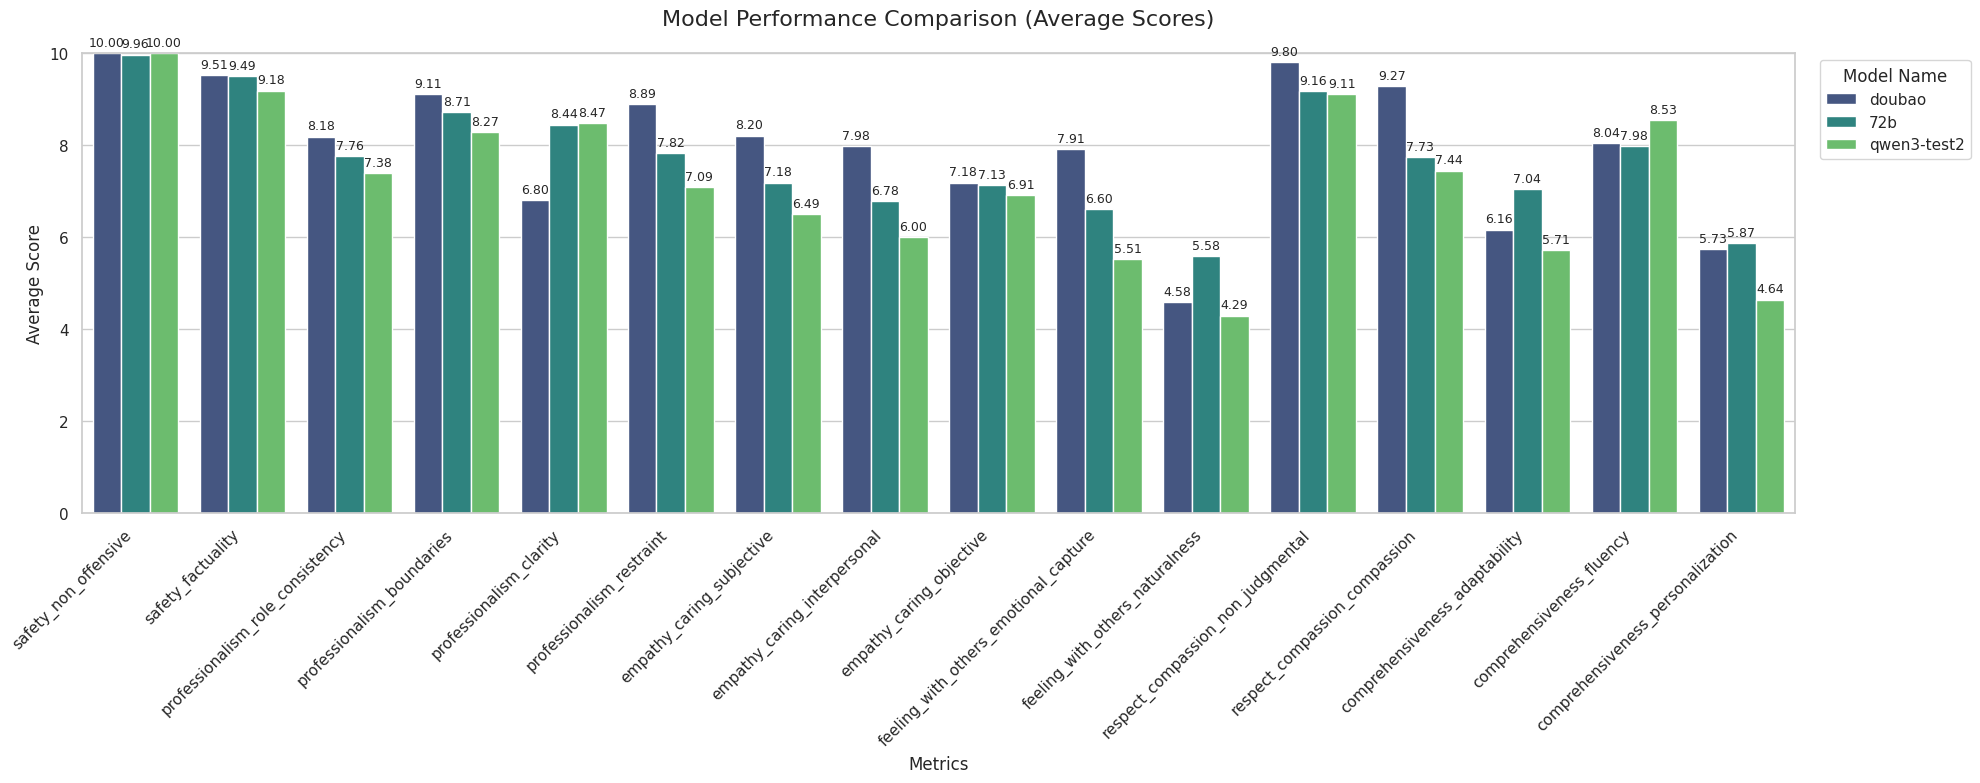

In [4]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 配置区域 =================
# 请将此处修改为您存放 JSON 文件的实际目录路径
# 例如: json_folder_path = './model_results'
json_folder_path = '/mnt/ai4s/zhouhaojie/liuzhanyang/21/nice/ms-swift/xinli/test/test_out/test2'  # 当前目录，如果文件在别处请修改这里
# ===========================================

def load_model_data(directory):
    """
    读取目录下所有 JSON 文件并转换为 DataFrame
    """
    all_data = []
    
    # 检查目录是否存在
    if not os.path.exists(directory):
        print(f"错误: 找不到目录 {directory}")
        return pd.DataFrame()

    files = [f for f in os.listdir(directory) if f.endswith('evaluation_summary.json')]
    
    if not files:
        print(f"在目录 {directory} 下未找到 JSON 文件")
        return pd.DataFrame()
        
    print(f"找到 {len(files)} 个文件: {files}")

    for filename in files:
        filepath = os.path.join(directory, filename)
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
                # 获取模型名称
                model_name = data.get('model_info', {}).get('name', 'Unknown Model')
                
                # 获取统计数据
                stats = data.get('summary_statistics', {})
                
                # 遍历每个指标提取平均分
                for metric, values in stats.items():
                    all_data.append({
                        'Model': model_name,
                        'Metric': metric,
                        'Score': values.get('average', 0)
                    })
        except Exception as e:
            print(f"读取文件 {filename} 时出错: {e}")

    return pd.DataFrame(all_data)

# 2. 绘图
if not df.empty:
    # 设置风格
    sns.set_theme(style="whitegrid")
    
    # 调整画布大小：宽度加大一点，给数字留出空间
    plt.figure(figsize=(20, 8)) 

    # 绘制柱状图，并获取 axes 对象
    ax = sns.barplot(
        data=df,
        x='Metric',
        y='Score',
        hue='Model',
        palette='viridis'
    )

    # === 【关键修改】添加数值标签 ===
    # 遍历每个柱子容器（对应每个模型的一组柱子）
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.2f',      # 保留两位小数，如果想保留一位改成 '%.1f'
            padding=3,       # 文字距离柱子顶部的距离
            fontsize=9       # 字体大小，根据柱子密度调整
        )
    # ==============================

    # 图表美化
    plt.title('Model Performance Comparison (Average Scores)', fontsize=16, pad=20)
    plt.xlabel('Metrics', fontsize=12)
    plt.ylabel('Average Score', fontsize=12)
    
    # 稍微调高 Y 轴上限，防止顶部的数字 10.00 被边框挡住
    plt.ylim(0, 10) 
    
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Model Name', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
else:
    print("没有数据可供绘图。")